# Churn Prediction Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report, roc_curve, precision_score
)

np.random.seed(42)

# Dark theme rcParams
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#16213e',
    'legend.facecolor': '#16213e',
    'legend.edgecolor': 'white',
    'legend.labelcolor': 'white',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.facecolor': '#1a1a2e',
})

# Load data
households = pd.read_csv('../data/households.csv')
network_events = pd.read_csv('../data/network_events.csv')
user_sessions = pd.read_csv('../data/user_sessions.csv')

print(f'Households: {households.shape}')
print(f'Network Events: {network_events.shape}')
print(f'User Sessions: {user_sessions.shape}')
print()
print(households.head())

/Users/harthikmallichetty/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Households: (5000, 10)
Network Events: (450000, 7)
User Sessions: (373313, 6)

  household_id device_model firmware_version  plan_type     region  num_nodes  \
0     HH-00000      eero 6+            6.4.0      Basic    Midwest          3   
1     HH-00001     eero Max            6.4.0      Basic  Southwest          1   
2     HH-00002  eero Pro 6E            6.5.0      Basic    Midwest          2   
3     HH-00003      eero 6+            6.3.0  eero Plus  Northeast          3   
4     HH-00004       eero 6            6.5.0  eero Plus  Northeast          2   

   connected_devices  tenure_days signup_date  churned  
0                 15          135  2023-08-19        1  
1                 15          899  2021-07-16        0  
2                 15          381  2022-12-16        0  
3                 19          877  2021-08-07        0  
4                 23           77  2023-10-16        0  


## Feature Engineering

In [2]:
# Sort network events by household and date for rolling calculations
network_events['date'] = pd.to_datetime(network_events['date'])
network_events = network_events.sort_values(['household_id', 'date'])

# Rolling 7-day average of connection_drops per household
network_events['avg_drops_7d'] = (
    network_events.groupby('household_id')['connection_drops']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Rolling 30-day average latency per household
network_events['avg_latency_30d'] = (
    network_events.groupby('household_id')['avg_latency_ms']
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

# Aggregate network features per household (take last rolling value + total offline)
net_agg = network_events.groupby('household_id').agg(
    avg_drops_7d=('avg_drops_7d', 'last'),
    avg_latency_30d=('avg_latency_30d', 'last'),
    total_offline_minutes=('offline_duration_minutes', 'sum')
).reset_index()

# User session features
user_sessions['date'] = pd.to_datetime(user_sessions['date'])

session_agg = user_sessions.groupby('household_id').agg(
    support_tickets_total=('support_ticket_raised', 'sum'),
    unique_features=('feature_used', 'nunique'),
    avg_app_opens=('app_opens', 'mean')
).reset_index()

session_agg['feature_diversity_score'] = session_agg['unique_features'] / 5

# Merge everything with households
df = households.merge(net_agg, on='household_id', how='left')
df = df.merge(session_agg[['household_id', 'support_tickets_total', 'feature_diversity_score', 'avg_app_opens']],
              on='household_id', how='left')

# Fill NaN values
df = df.fillna(0)

# Label encode categorical features
le_firmware = LabelEncoder()
df['firmware_version_enc'] = le_firmware.fit_transform(df['firmware_version'])

le_plan = LabelEncoder()
df['plan_type_enc'] = le_plan.fit_transform(df['plan_type'])

# Define feature columns and target
feature_cols = [
    'firmware_version_enc', 'plan_type_enc', 'num_nodes', 'tenure_days',
    'avg_drops_7d', 'avg_latency_30d', 'support_tickets_total',
    'feature_diversity_score', 'connected_devices'
]

X = df[feature_cols]
y = df['churned']

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Feature matrix shape: (5000, 9)
Target distribution:
churned
0    4394
1     606
Name: count, dtype: int64


## Train/Test Split

In [3]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train_scaled.shape[0]} samples')
print(f'Test set:  {X_test_scaled.shape[0]} samples')
print()
print('Class distribution (train):')
print(y_train.value_counts().to_frame('count').assign(
    pct=lambda d: (d['count'] / d['count'].sum() * 100).round(1)
))
print()
print('Class distribution (test):')
print(y_test.value_counts().to_frame('count').assign(
    pct=lambda d: (d['count'] / d['count'].sum() * 100).round(1)
))

Train set: 4000 samples
Test set:  1000 samples

Class distribution (train):
         count   pct
churned             
0         3515  87.9
1          485  12.1

Class distribution (test):
         count   pct
churned             
0          879  87.9
1          121  12.1


## Model Training

In [4]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_preds = gb_model.predict(X_test_scaled)
gb_probs = gb_model.predict_proba(X_test_scaled)[:, 1]

print('Models trained successfully.')
print(f'Logistic Regression - predictions shape: {lr_preds.shape}')
print(f'Gradient Boosting   - predictions shape: {gb_preds.shape}')

Models trained successfully.
Logistic Regression - predictions shape: (1000,)
Gradient Boosting   - predictions shape: (1000,)


## Model Evaluation

In [5]:
def compute_metrics(y_true, y_pred, y_prob, model_name):
    """Compute ROC-AUC, PR-AUC, and Precision@10%."""
    # ROC-AUC
    roc_auc = roc_auc_score(y_true, y_prob)

    # PR-AUC
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_vals, precision_vals)

    # Precision@10% - precision at top 10% of predicted probabilities
    n_top = max(1, int(len(y_prob) * 0.10))
    top_indices = np.argsort(y_prob)[::-1][:n_top]
    precision_at_10 = y_true.values[top_indices].mean()

    return {
        'Model': model_name,
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'Precision@10%': round(precision_at_10, 4)
    }

lr_metrics = compute_metrics(y_test, lr_preds, lr_probs, 'Logistic Regression')
gb_metrics = compute_metrics(y_test, gb_preds, gb_probs, 'Gradient Boosting')

comparison_df = pd.DataFrame([lr_metrics, gb_metrics]).set_index('Model')
print('Model Comparison:')
print(comparison_df.to_string())

Model Comparison:
                     ROC-AUC  PR-AUC  Precision@10%
Model                                              
Logistic Regression   0.9618  0.8491           0.85
Gradient Boosting     0.9347  0.8001           0.80


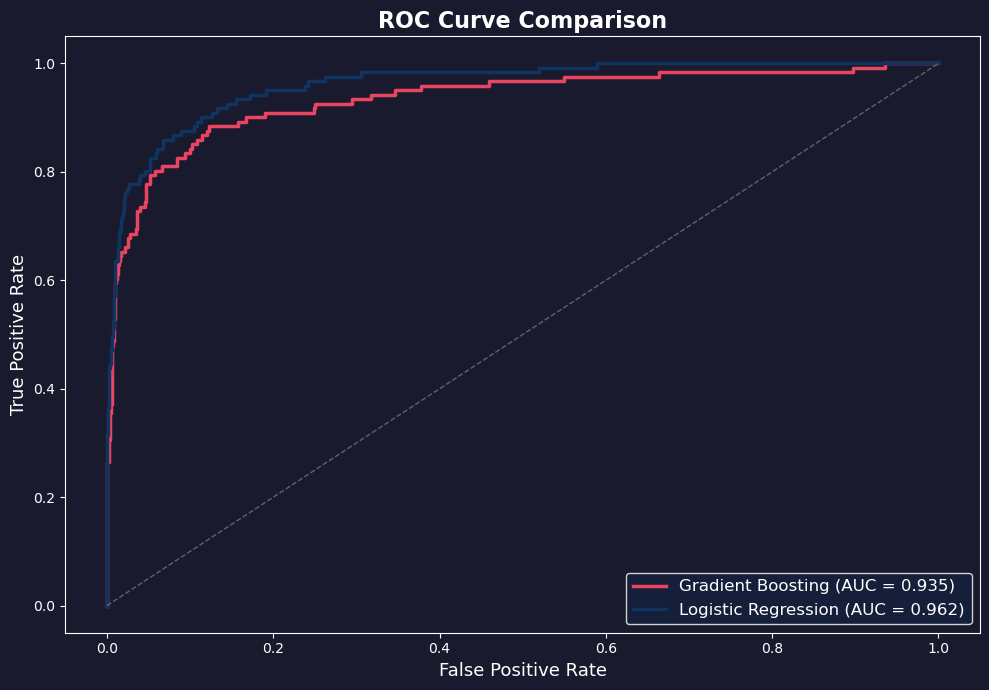

Saved: ../images/model_performance_comparison.png


In [6]:
# ROC Curves for both models
fig, ax = plt.subplots(figsize=(10, 7))

# Gradient Boosting ROC
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
gb_roc_auc = roc_auc_score(y_test, gb_probs)
ax.plot(gb_fpr, gb_tpr, color='#e94560', linewidth=2.5,
        label=f'Gradient Boosting (AUC = {gb_roc_auc:.3f})')

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_roc_auc = roc_auc_score(y_test, lr_probs)
ax.plot(lr_fpr, lr_tpr, color='#0f3460', linewidth=2.5,
        label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')

# Diagonal reference line
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model_performance_comparison.png', dpi=300, facecolor='#1a1a2e',
            bbox_inches='tight')
plt.show()
print('Saved: ../images/model_performance_comparison.png')

## Feature Importance

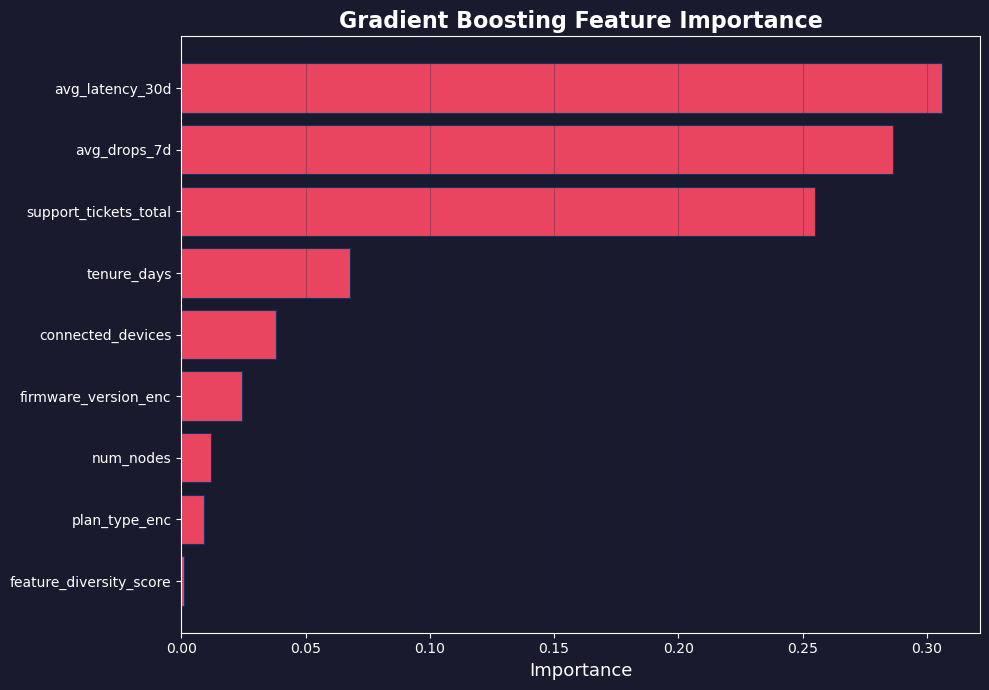

Saved: ../images/feature_importance.png


In [7]:
# Feature importances from Gradient Boosting
importances = gb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
               color='#e94560', edgecolor='#0f3460', linewidth=0.8)

ax.set_xlabel('Importance', fontsize=13)
ax.set_title('Gradient Boosting Feature Importance', fontsize=16, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=300, facecolor='#1a1a2e',
            bbox_inches='tight')
plt.show()
print('Saved: ../images/feature_importance.png')

## Confusion Matrix

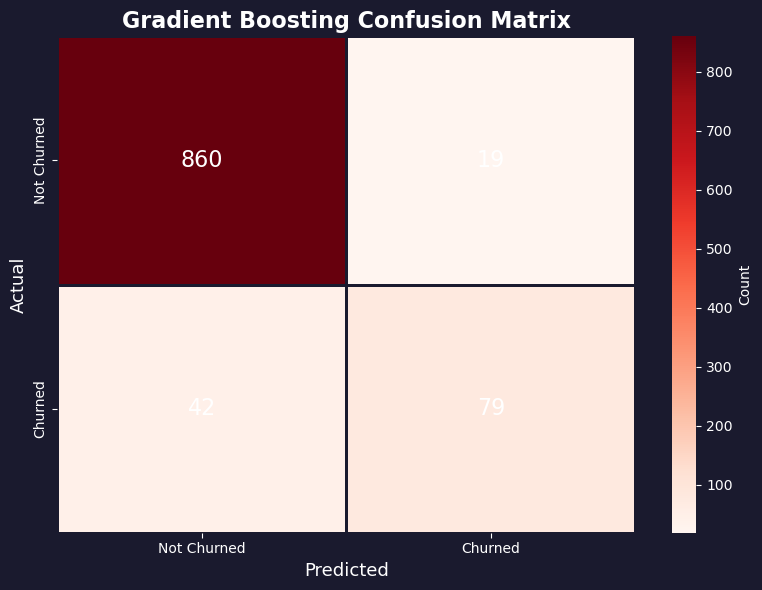


Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

 Not Churned       0.95      0.98      0.97       879
     Churned       0.81      0.65      0.72       121

    accuracy                           0.94      1000
   macro avg       0.88      0.82      0.84      1000
weighted avg       0.94      0.94      0.94      1000



In [8]:
# Confusion matrix for Gradient Boosting
cm = confusion_matrix(y_test, gb_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            annot_kws={'size': 16, 'color': 'white'},
            linewidths=2, linecolor='#1a1a2e',
            cbar_kws={'label': 'Count'})

# Fix colorbar label color for dark theme
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Gradient Boosting Confusion Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report (Gradient Boosting):')
print(classification_report(y_test, gb_preds, target_names=['Not Churned', 'Churned']))

## Cost-Benefit Threshold Analysis

Optimal Threshold: 0.10
Maximum Net Savings: $10,512.00


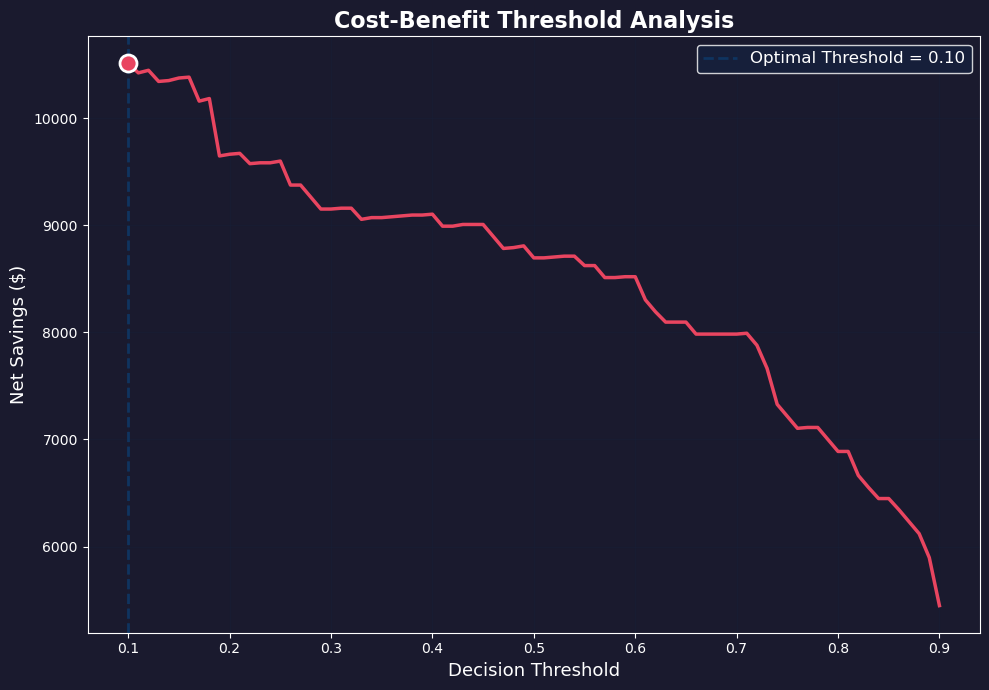

In [9]:
# Cost-benefit analysis
cost_losing_customer = 120  # $/year
cost_retention_outreach = 8  # $

thresholds = np.arange(0.1, 0.91, 0.01)
net_savings_list = []

y_test_arr = y_test.values

for thresh in thresholds:
    preds_t = (gb_probs >= thresh).astype(int)
    tp = np.sum((preds_t == 1) & (y_test_arr == 1))
    fp = np.sum((preds_t == 1) & (y_test_arr == 0))
    fn = np.sum((preds_t == 0) & (y_test_arr == 1))
    tn = np.sum((preds_t == 0) & (y_test_arr == 0))

    net_savings = tp * cost_losing_customer - (tp + fp) * cost_retention_outreach
    net_savings_list.append(net_savings)

net_savings_arr = np.array(net_savings_list)
optimal_idx = np.argmax(net_savings_arr)
optimal_threshold = thresholds[optimal_idx]
optimal_savings = net_savings_arr[optimal_idx]

print(f'Optimal Threshold: {optimal_threshold:.2f}')
print(f'Maximum Net Savings: ${optimal_savings:,.2f}')

# Plot threshold vs net savings
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(thresholds, net_savings_arr, color='#e94560', linewidth=2.5)
ax.axvline(x=optimal_threshold, color='#0f3460', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {optimal_threshold:.2f}')
ax.scatter([optimal_threshold], [optimal_savings], color='#e94560', s=150,
           zorder=5, edgecolors='white', linewidth=2)

ax.set_xlabel('Decision Threshold', fontsize=13)
ax.set_ylabel('Net Savings ($)', fontsize=13)
ax.set_title('Cost-Benefit Threshold Analysis', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

In [10]:
# Final summary
print('=' * 65)
print('        CHURN PREDICTION MODEL - FINAL SUMMARY')
print('=' * 65)
print()

summary_data = {
    'Metric': ['ROC-AUC', 'PR-AUC', 'Precision@10%'],
    'Logistic Regression': [
        lr_metrics['ROC-AUC'],
        lr_metrics['PR-AUC'],
        lr_metrics['Precision@10%']
    ],
    'Gradient Boosting': [
        gb_metrics['ROC-AUC'],
        gb_metrics['PR-AUC'],
        gb_metrics['Precision@10%']
    ]
}

summary_df = pd.DataFrame(summary_data).set_index('Metric')
print('Model Performance Comparison:')
print(summary_df.to_string())
print()
print(f'Optimal Decision Threshold:  {optimal_threshold:.2f}')
print(f'Expected Net Savings:        ${optimal_savings:,.2f}/year')
print(f'Cost of Losing Customer:     ${cost_losing_customer}/year')
print(f'Cost of Retention Outreach:  ${cost_retention_outreach}')
print()
print('Top 3 Most Important Features (Gradient Boosting):')
top3 = feature_importance_df.sort_values('Importance', ascending=False).head(3)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f'  {i}. {row["Feature"]:30s} {row["Importance"]:.4f}')
print()
print('=' * 65)

        CHURN PREDICTION MODEL - FINAL SUMMARY

Model Performance Comparison:
               Logistic Regression  Gradient Boosting
Metric                                               
ROC-AUC                     0.9618             0.9347
PR-AUC                      0.8491             0.8001
Precision@10%               0.8500             0.8000

Optimal Decision Threshold:  0.10
Expected Net Savings:        $10,512.00/year
Cost of Losing Customer:     $120/year
Cost of Retention Outreach:  $8

Top 3 Most Important Features (Gradient Boosting):
  1. avg_latency_30d                0.3061
  2. avg_drops_7d                   0.2864
  3. support_tickets_total          0.2549

